# Ocular Disease Recognition — EDA & Preprocessing

Exploratory analysis and preprocessing pipeline for the **ODIR-5K** retinal fundus image dataset.
Outputs `train_data.h5` and `test_data.h5` consumed by `02_model_training.ipynb`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import random

from sklearn.model_selection import train_test_split


# 1. Data Loading & Cleaning

Load raw metadata from `full_df.csv` and inspect the column structure.

In [3]:
data = pd.read_csv('../Main/full_df.csv')
data.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


## 1.1 Dataset Size

In [4]:
print(f"total len: {len(data)}, len train: {len(data)*0.8}, len test: {len(data)*0.2}")

total len: 6392, len train: 5113.6, len test: 1278.4


## 1.2 Class Distribution

Inspect class imbalance. The dataset is heavily skewed toward Normal (N) and Diabetic Retinopathy (D).

In [5]:
print(data['labels'].value_counts())

labels
['N']    2873
['D']    1608
['O']     708
['C']     293
['G']     284
['A']     266
['M']     232
['H']     128
Name: count, dtype: int64


## 1.3 Drop Redundant Columns

Remove per-eye diagnostic keywords, per-eye image paths, and the original Kaggle `filepath`. Only binary diagnosis flags, patient metadata, and `filename` are retained.

In [6]:
data = data.drop(columns=['Right-Diagnostic Keywords', 'Left-Diagnostic Keywords', 'Left-Fundus', 'Right-Fundus'])
data.head()

,ID,Patient Age,Patient Sex,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


Set the path to `preprocessed_images/` and verify filesystem access.

In [7]:
FILEPATH = "../preprocessed_images"

first_file = os.listdir(FILEPATH)[0]
print(first_file)

0_left.jpg


The `filepath` column references the original Kaggle directory structure, incompatible with this project layout. Drop it.

In [8]:
data = data.drop(columns=['filepath'])
data.head()

,ID,Patient Age,Patient Sex,N,D,G,C,A,H,M,O,labels,target,filename
0,0,69,Female,0,0,0,1,0,0,0,0,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1,0,0,0,0,0,0,0,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,0,1,0,0,0,0,0,1,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,0,1,0,0,0,0,0,1,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,0,1,0,0,0,0,0,0,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


## 1.4 Consolidate Diagnosis Labels

Merge the 8 binary columns (`N`, `D`, `G`, `C`, `A`, `H`, `M`, `O`) into a single `diagnostic` string (e.g. `DO` = Diabetic + Other). Drop the originals.

In [9]:

data['diagnostic'] = data.apply(lambda row: ''.join([col for col in ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O'] if row[col] == 1]), axis=1)

data = data.drop(columns=['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O'])

data.head()

,ID,Patient Age,Patient Sex,labels,target,filename,diagnostic
0,0,69,Female,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg,C
1,1,57,Male,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg,N
2,2,42,Male,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg,DO
3,4,53,Male,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg,DO
4,5,50,Female,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg,D


Combined diagnosis codes reflect patients with co-occurring conditions. `DO` (464 cases) is the most common multi-label combination.

In [10]:
print(data['diagnostic'].value_counts())

diagnostic
N      2101
D      1376
O       894
DO      464
C       276
A       234
G       232
M       206
DH       88
H        72
DC       62
GO       57
MO       51
CO       42
DG       42
DA       28
DM       26
AO       23
GA       19
HO       15
DCO      12
DGO      12
GH       10
GM       10
AH        8
DMO       6
GHO       5
CH        4
GC        4
GCO       2
DAM       2
DGM       2
DAO       2
AM        2
DHO       1
GMO       1
GAO       1
Name: count, dtype: int64


## 1.5 Single-Eye Records

324 patient IDs have only one eye recorded. These records are retained — they represent valid single-label data points.

In [11]:
id_counts = data['ID'].value_counts()
id_counts[id_counts != 2].index.tolist()


[2,
 38,
 50,
 66,
 74,
 78,
 89,
 90,
 108,
 114,
 141,
 183,
 188,
 192,
 195,
 201,
 208,
 222,
 224,
 236,
 242,
 261,
 276,
 280,
 283,
 293,
 305,
 336,
 342,
 361,
 378,
 393,
 403,
 414,
 417,
 418,
 427,
 438,
 441,
 443,
 470,
 478,
 485,
 494,
 497,
 506,
 516,
 518,
 528,
 548,
 592,
 593,
 612,
 624,
 679,
 705,
 720,
 751,
 768,
 795,
 819,
 840,
 841,
 844,
 845,
 905,
 908,
 940,
 955,
 991,
 993,
 1005,
 1014,
 1018,
 1033,
 1061,
 1062,
 1066,
 1077,
 1116,
 1121,
 1127,
 1130,
 1142,
 1145,
 1148,
 1177,
 1242,
 1243,
 1254,
 1263,
 1273,
 1310,
 1319,
 1412,
 1475,
 1540,
 1560,
 1567,
 1573,
 1574,
 1581,
 1585,
 1595,
 1597,
 1614,
 1642,
 1652,
 1657,
 1659,
 1664,
 1677,
 1683,
 1706,
 1799,
 1801,
 1865,
 2102,
 2139,
 2231,
 2244,
 2251,
 2400,
 2495,
 2496,
 2571,
 2580,
 2589,
 2611,
 2629,
 2676,
 2737,
 2739,
 2751,
 2752,
 2756,
 2851,
 2893,
 2930,
 2959,
 3037,
 3039,
 3046,
 3164,
 3181,
 3238,
 3239,
 3256,
 3320,
 3346,
 3383,
 3935,
 4007,
 4169,
 4

In [12]:
print(len(id_counts[id_counts != 2]))

324


## 1.6 Target Encoding

Inspect column types, then parse the stringified one-hot `target` vector into a Python list.

In [13]:
print(data.dtypes)
data['target'] = data['target'].apply(lambda x: list(map(int, x.strip('[]').split(','))))

ID             int64
Patient Age    int64
Patient Sex      str
labels           str
target           str
filename         str
diagnostic       str
dtype: object


Convert the one-hot list to a scalar class index (position of `1`) and drop the now-redundant `labels` column.

In [14]:
data['target'] = data['target'].apply(lambda x: x.index(1))
data = data.drop(columns=['labels'])
print(data.head())

   ID  Patient Age Patient Sex  target     filename diagnostic
0   0           69      Female       0  0_right.jpg          C
1   1           57        Male       0  1_right.jpg          N
2   2           42        Male       1  2_right.jpg         DO
3   4           53        Male       1  4_right.jpg         DO
4   5           50      Female       1  5_right.jpg          D


In [15]:
classes = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
classes

['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

In [16]:
classes_details = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract', 'Age-related Macular Degeneration', 'Hypertension', 'Myopia', 'Other'] 

In [17]:
data.to_csv('../Main/preprocessed_data.csv', index=False)

# 2. Exploratory Data Analysis

In [18]:
RED = '#f54242'
BLUE = '#42c8f5'

## 2.1 Class Distribution by Gender

The male population is slightly larger overall; females are more represented in certain disease categories.

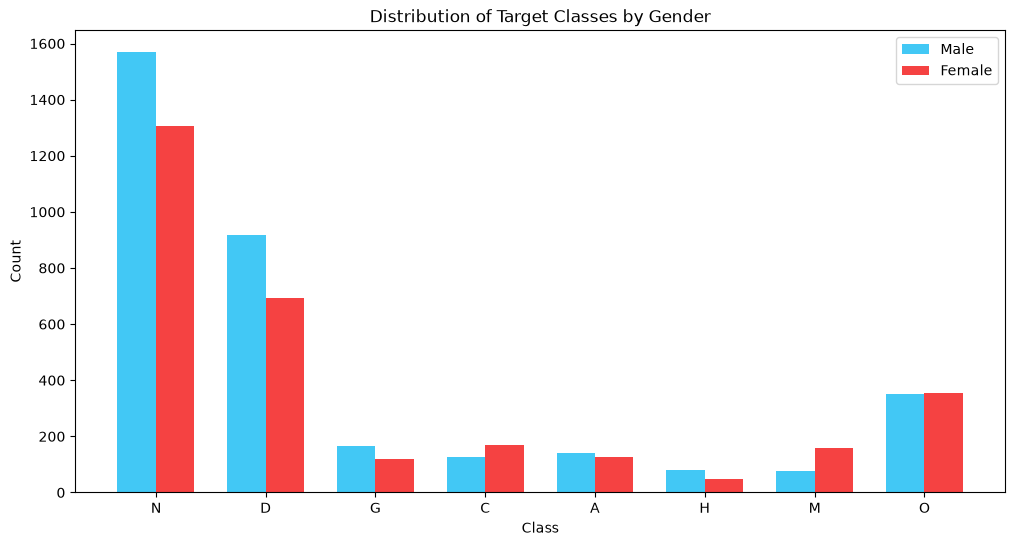

In [19]:
male_counts = data[data['Patient Sex'] == 'Male']['target'].value_counts().sort_index()
female_counts = data[data['Patient Sex'] == 'Female']['target'].value_counts().sort_index()

male_counts = male_counts.reindex(range(len(classes)), fill_value=0)
female_counts = female_counts.reindex(range(len(classes)), fill_value=0)

bar_width = 0.35
index = np.arange(len(classes))

plt.figure(figsize=(12, 6))
plt.bar(index, male_counts, bar_width, label='Male', color=BLUE)
plt.bar(index + bar_width, female_counts, bar_width, label='Female', color=RED)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Target Classes by Gender')
plt.xticks(index + bar_width / 2, classes)
plt.legend()
plt.savefig('../figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Healthy vs. Diseased

Normal (N) comprises 45% of the dataset. All other classes combined represent the diseased population.

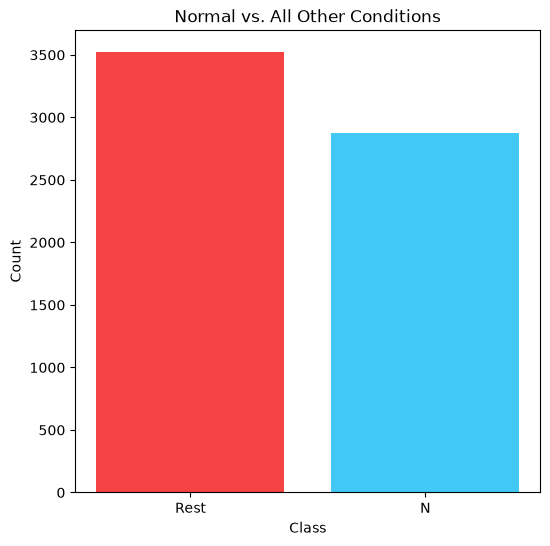

In [20]:
data['binary_target'] = data['target'].apply(lambda x: 1 if x == 0 else 0)
binary_counts = data['binary_target'].value_counts()

plt.figure(figsize=(6, 6))
plt.bar(['Rest', 'N'], binary_counts, color=[RED, BLUE])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Normal vs. All Other Conditions')
plt.savefig('../figures/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Age Distribution

Peak patient age is around 60 years, consistent with the prevalence of age-related ocular conditions.

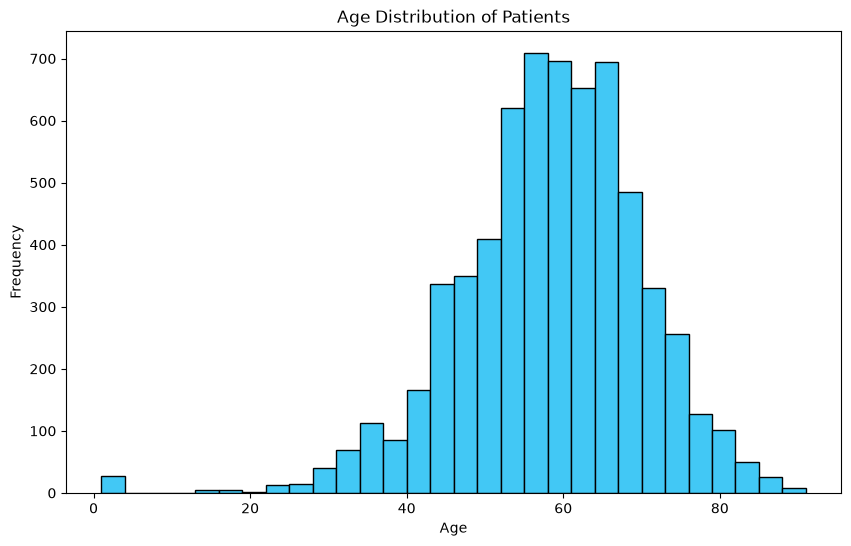

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(data['Patient Age'], bins=30, color=BLUE, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Patients')
plt.show()

## 2.4 Sex Distribution

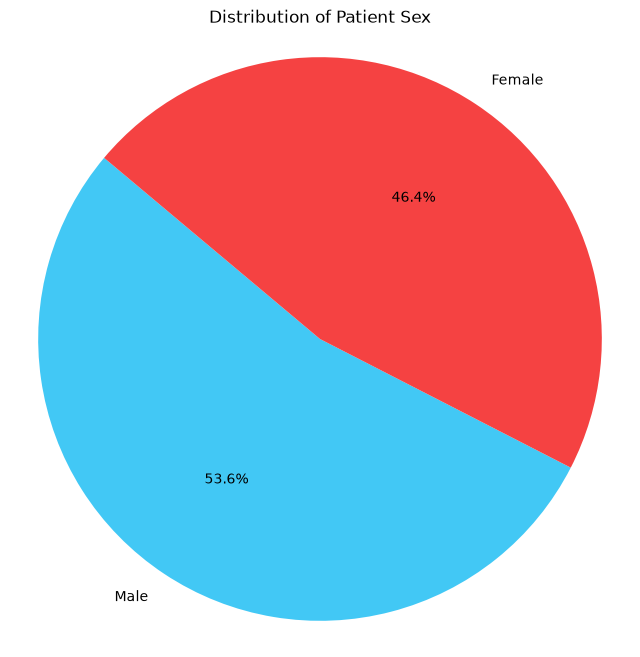

In [22]:
sex_counts = data['Patient Sex'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', colors=[BLUE, RED], startangle=140)
plt.title('Distribution of Patient Sex')
plt.axis('equal') 
plt.show()

## 2.5 Sample Images per Class

Ten representative 512×512 fundus images for each diagnostic category.

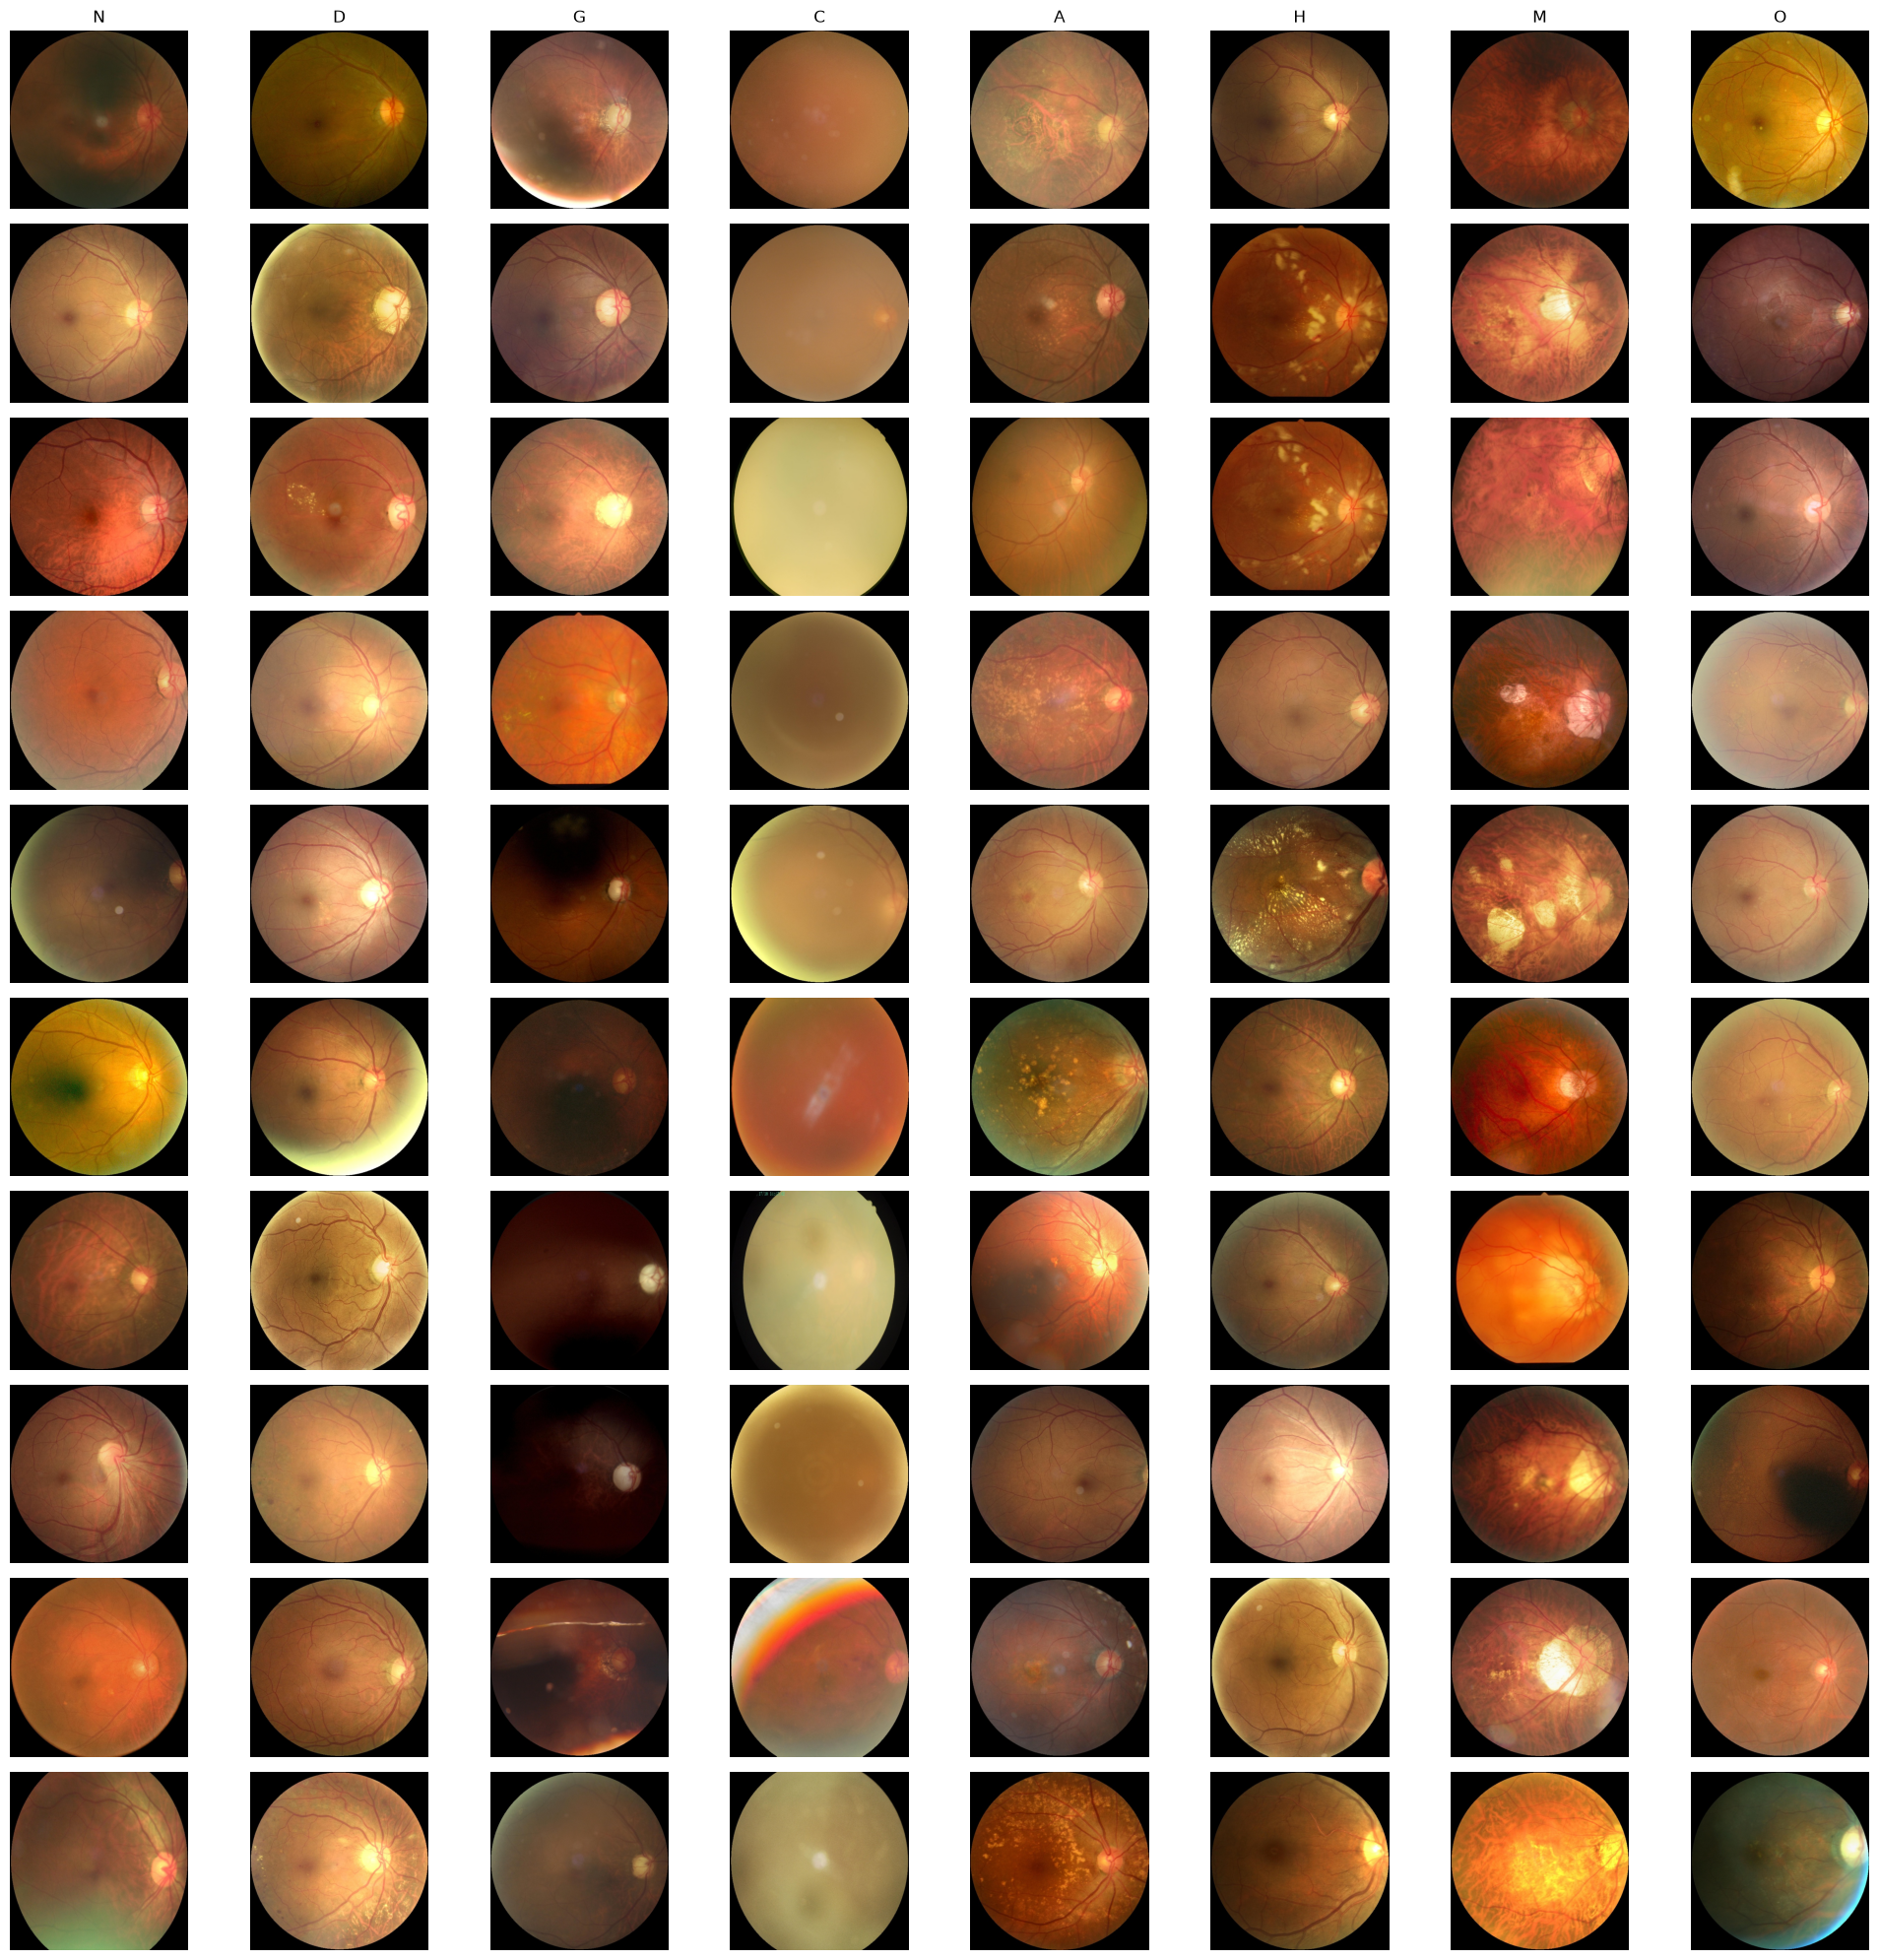

In [23]:
fig, axes = plt.subplots(nrows=10, ncols=len(classes), figsize=(20, 20))

for i, cls in enumerate(classes):
    class_images = data[data['target'] == i]['filename'].head(10)
    for j, img_name in enumerate(class_images):
        img_path = os.path.join(FILEPATH, img_name)
        img = plt.imread(img_path)
        axes[j, i].imshow(img)
        axes[j, i].axis('off')
        if j == 0:
            axes[j, i].set_title(cls)

plt.tight_layout()
plt.savefig('../figures/sample_images_per_class.png', dpi=100, bbox_inches='tight')
plt.show()

## 2.6 Bilateral Sample

Left and right fundus images from the same patient — illustrates the paired structure of the ODIR-5K dataset.

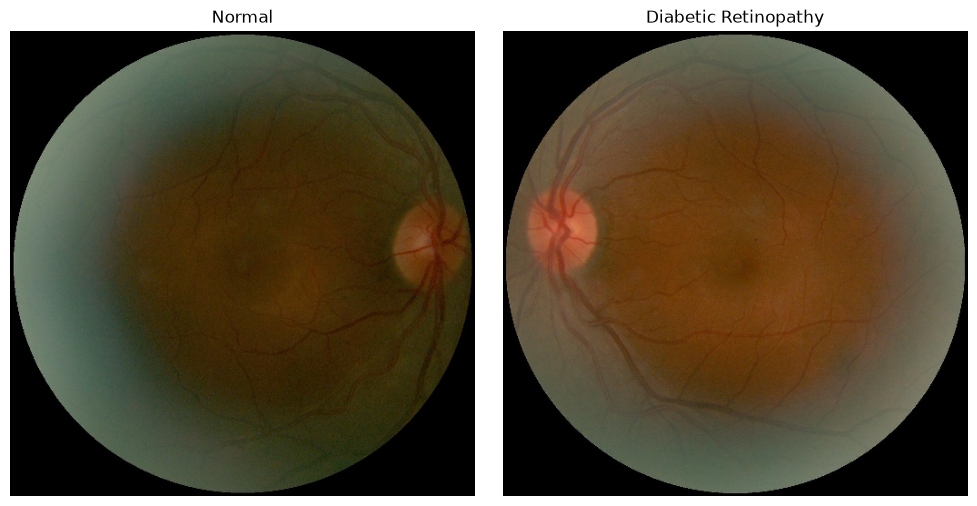

In [24]:
excluded_ids = id_counts[id_counts != 2].index.tolist()
valid_data = data[~data['ID'].isin(excluded_ids)]

random_id = random.choice(valid_data['ID'].unique())

patient_images = valid_data[valid_data['ID'] == random_id]['filename'].tolist()
patient_classes = valid_data[valid_data['ID'] == random_id]['target'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, (img_name, cls) in enumerate(zip(patient_images, patient_classes)):
    img_path = os.path.join(FILEPATH, img_name)
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(classes_details[cls])

plt.tight_layout()
plt.show()

## 2.7 Image Dimensions

Verify that all images conform to the expected 512×512×3 format.

In [25]:
for img_name in data['filename'].head(10): 
    img_path = os.path.join(FILEPATH, img_name)
    img = plt.imread(img_path)
    print(f"Image: {img_name}, Dimensions: {img.shape}")

Image: 0_right.jpg, Dimensions: (512, 512, 3)
Image: 1_right.jpg, Dimensions: (512, 512, 3)
Image: 2_right.jpg, Dimensions: (512, 512, 3)
Image: 4_right.jpg, Dimensions: (512, 512, 3)
Image: 5_right.jpg, Dimensions: (512, 512, 3)
Image: 6_right.jpg, Dimensions: (512, 512, 3)
Image: 7_right.jpg, Dimensions: (512, 512, 3)
Image: 8_right.jpg, Dimensions: (512, 512, 3)
Image: 9_right.jpg, Dimensions: (512, 512, 3)
Image: 10_right.jpg, Dimensions: (512, 512, 3)


Scan for any images with non-standard dimensions (expected: none).

In [26]:
for img_name in data['filename']:
    img_path = os.path.join(FILEPATH, img_name)
    img = plt.imread(img_path)
    if img.shape != (512, 512, 3):
        print(f"Image: {img_name}, Dimensions: {img.shape}")

# 3. Train / Test Split

Stratified 80/20 split preserving class proportions. `random_state=511` is fixed for reproducibility.

In [27]:
train_data, test_data = train_test_split(data, test_size=0.2, stratify=data['target'], random_state=511) #OCT 5TH

print(f"Train data length: {len(train_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 5113
Test data length: 1279


Serialize train and test splits to HDF5. These files are the inputs to `02_model_training.ipynb`.

In [28]:
train_data.to_hdf('../Main/train_data.h5', key='train', mode='w')
test_data.to_hdf('../Main/test_data.h5', key='test', mode='w')